In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 定义统一的颜色
LEGEND_COLOR = "#c8c8e1"

DARK_BLUE = "#526d9f"
LIGHT_PURPLE = "#beaad1"


LIGHT_ORANGE = "#F5C89A"
DARK_ORANGE = "#C9896D" 
# BG_PURPLE = "#EEEEF2"

# 使用seaborn方式设置背景
sns.set_theme(style="darkgrid")


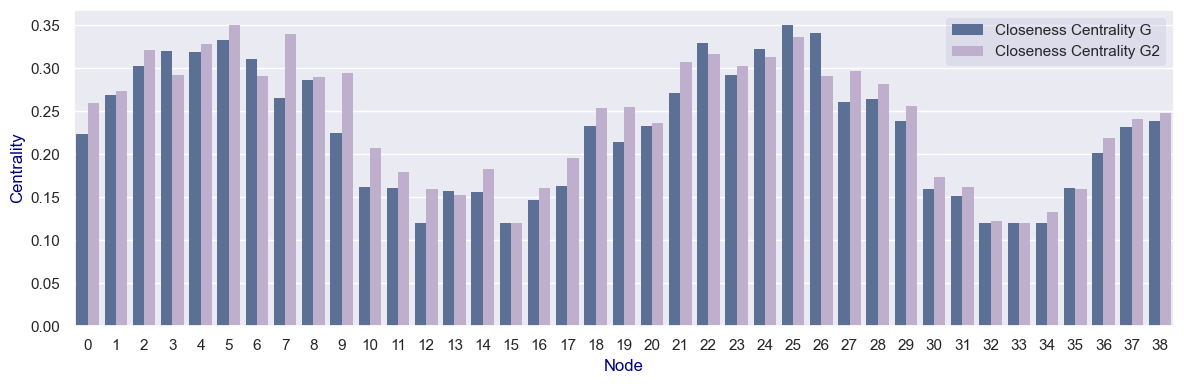

In [ ]:
# 定义统一的颜色
LEGEND_COLOR = "#c8c8e1"

DARK_BLUE = "#526d9f"
LIGHT_PURPLE = "#beaad1"


LIGHT_ORANGE = "#F5C89A"
DARK_ORANGE = "#C9896D" 
# BG_PURPLE = "#EEEEF2"

# 使用seaborn方式设置背景
sns.set_theme(style="darkgrid")

nodes = np.arange(39)
base = 0.2 + 0.1 * np.sin(nodes / 3) + 0.05 * np.random.rand(len(nodes))
closeness_g = np.clip(base + 0.02 * np.random.randn(len(nodes)), 0.12, 0.35)
closeness_g2 = np.clip(base + 0.01 + 0.02 * np.random.randn(len(nodes)), 0.12, 0.35)

df = pd.DataFrame({
    "Node": np.concatenate([nodes, nodes]),
    "Closeness Centrality": np.concatenate([closeness_g, closeness_g2]),
    "Group": ["Closeness Centrality G"] * len(nodes) + ["Closeness Centrality G2"] * len(nodes)
})

plt.figure(figsize=(12, 4))
sns.barplot(data=df, x="Node", y="Closeness Centrality", hue="Group", palette=[DARK_BLUE, LIGHT_PURPLE], edgecolor="none")
plt.xlabel("Node", color="#000080")
plt.ylabel("Centrality", color="#000080")
plt.legend(title=None, facecolor=LEGEND_COLOR, edgecolor="none", framealpha=0.4)

plt.tight_layout()


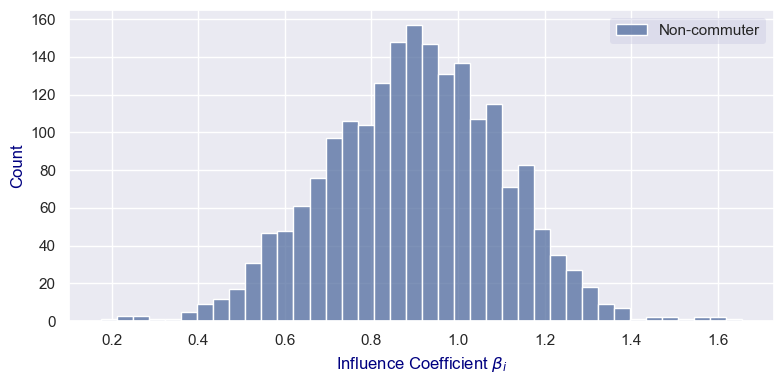

In [131]:
influence = np.random.normal(loc=0.9, scale=0.2, size=2000)
influence = np.clip(influence, 0, 2.0)

plt.figure(figsize=(8, 4))
ax = plt.gca()

sns.histplot(influence, bins=40, color=DARK_BLUE, label="Non-commuter")
plt.xlabel(r"Influence Coefficient $\beta_i$", color="#000080")
plt.ylabel("Count", color="#000080")
plt.legend(title=None, facecolor=LEGEND_COLOR, edgecolor="none", framealpha=0.4)
plt.tight_layout()


C:\Users\Zhurun Zhang\AppData\Local\Temp\ipykernel_41772\1436057771.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


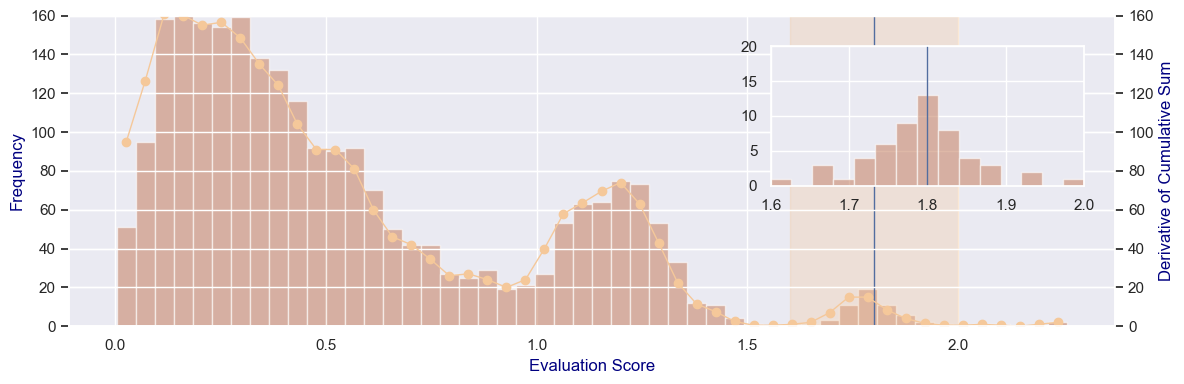

In [ ]:
scores = np.concatenate([
    np.random.gamma(shape=2.0, scale=0.2, size=2000),
    np.random.normal(loc=1.2, scale=0.1, size=400),
    np.random.normal(loc=1.8, scale=0.05, size=50)
])
scores = np.clip(scores, 0, 3.2)

fig, ax1 = plt.subplots(figsize=(12, 4))
counts, bins, _ = ax1.hist(scores, bins=50, alpha=0.6, color=DARK_ORANGE)
ax1.set_xlabel("Evaluation Score", color="#000080")
ax1.set_ylabel("Frequency", color="#000080")
ax1.set_ylim(0, 160)
ax1.tick_params(axis="y")

bin_centers = 0.5 * (bins[:-1] + bins[1:])
cumulative = np.cumsum(counts)
derivative = np.gradient(cumulative)

ax2 = ax1.twinx()
ax2.plot(bin_centers, derivative, marker="o", linewidth=1, color=LIGHT_ORANGE)
ax2.set_ylabel("Derivative of Cumulative Sum", color="#000080")
ax2.set_ylim(0, 160)
ax2.tick_params(axis="y")

ax1.axvspan(1.6, 2.0, color=LIGHT_ORANGE, alpha=0.3)
ax1.axvline(1.8, color=DARK_BLUE, linewidth=1)

ax_in = inset_axes(ax1, width="30%", height="45%", loc="upper right", borderpad=2)
ax_in.hist(scores, bins=15, range=(1.6, 2.0), alpha=0.6, color=DARK_ORANGE)
ax_in.axvline(1.8, color=DARK_BLUE, linewidth=1)
ax_in.set_xlim(1.6, 2.0)
ax_in.set_ylim(0, 20)

plt.tight_layout()


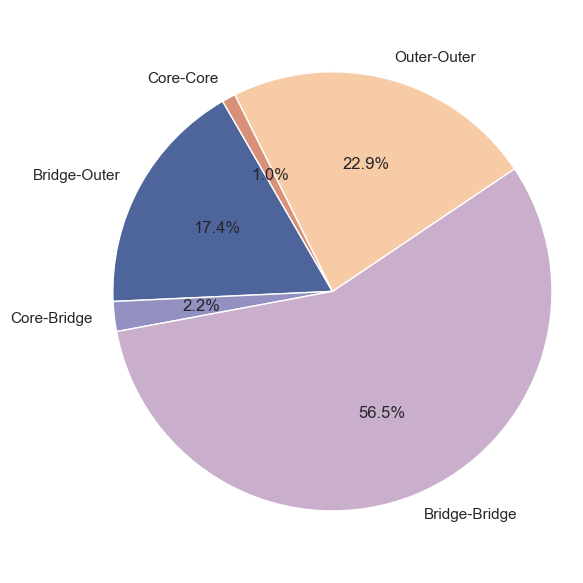

In [156]:
labels = ["Bridge-Outer", "Core-Bridge", "Bridge-Bridge", "Outer-Outer", "Core-Core"]
values = [17.4, 2.2, 56.5, 22.9, 1.0]
pie_colors = ["#4e659b", "#9291c2", "#c9afcc", "#f8cba7", "#d89079"]#"#c38d9e", "#B7D9C0", "#659dbd"]

plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=120, colors=pie_colors)#textprops={"color": "#5A5A7A"}
plt.axis("equal")
plt.tight_layout()


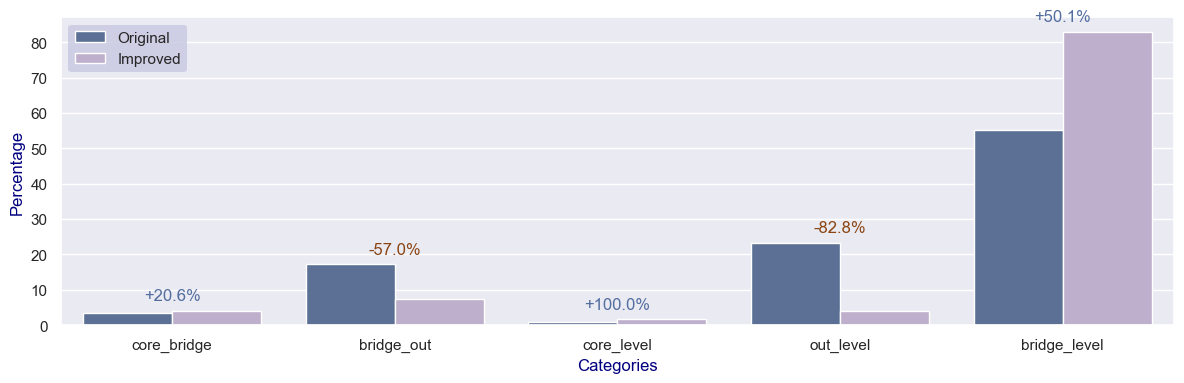

In [125]:
categories = ["core_bridge", "bridge_out", "core_level", "out_level", "bridge_level"]
original = np.array([3.4, 17.2, 0.8, 23.2, 55.3])
improved = np.array([4.1, 7.4, 1.6, 4.0, 83.0])

bar_df = pd.DataFrame({
    "Categories": categories + categories,
    "Value": list(original) + list(improved),
    "Type": ["Original"] * len(categories) + ["Improved"] * len(categories)
})

plt.figure(figsize=(12, 4))
ax = sns.barplot(data=bar_df, x="Categories", y="Value", hue="Type", palette=[DARK_BLUE, LIGHT_PURPLE])
ax.set_ylabel("Percentage", color="#000080")
ax.set_xlabel("Categories", color="#000080")

ax.legend(facecolor=LEGEND_COLOR, edgecolor="none")

for i, (o, n) in enumerate(zip(original, improved)):
    delta = (n - o) / o * 100 if o != 0 else 0
    color = "#8B4513" if delta < 0 else DARK_BLUE
    ax.text(i, max(o, n) + 3, f"{delta:+.1f}%", ha="center", color=color)

plt.tight_layout()


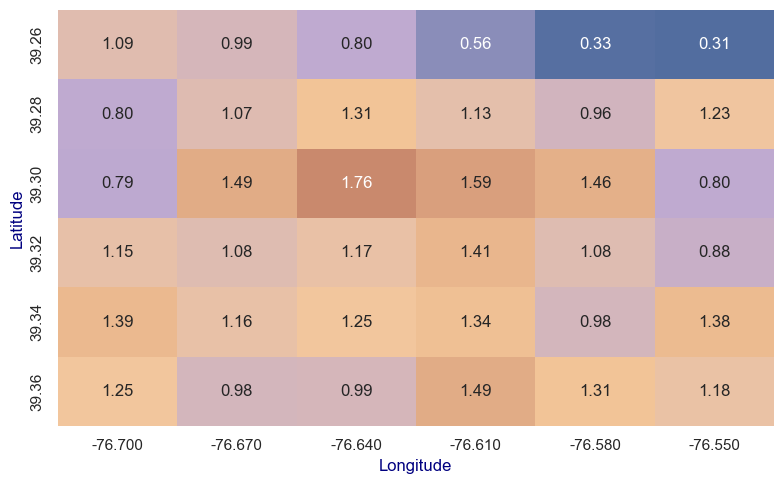

In [161]:
lat = np.linspace(39.26, 39.36, 6)
lon = np.linspace(-76.70, -76.55, 6)
values = np.array([
    [1.09, 0.99, 0.80, 0.56, 0.33, 0.31],
    [0.80, 1.07, 1.31, 1.13, 0.96, 1.23],
    [0.79, 1.49, 1.76, 1.59, 1.46, 0.80],
    [1.15, 1.08, 1.17, 1.41, 1.08, 0.88],
    [1.39, 1.16, 1.25, 1.34, 0.98, 1.38],
    [1.25, 0.98, 0.99, 1.49, 1.31, 1.18],
])

from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom", [DARK_BLUE, LIGHT_PURPLE, LIGHT_ORANGE, DARK_ORANGE])

plt.figure(figsize=(8, 5))
ax = sns.heatmap(values, annot=True, fmt=".2f", cmap=custom_cmap, cbar=False)
ax.set_xlabel("Longitude", color="#000080")
ax.set_ylabel("Latitude", color="#000080")
ax.set_xticklabels([f"{v:.3f}" for v in lon])
ax.set_yticklabels([f"{v:.2f}" for v in lat])
plt.tight_layout()


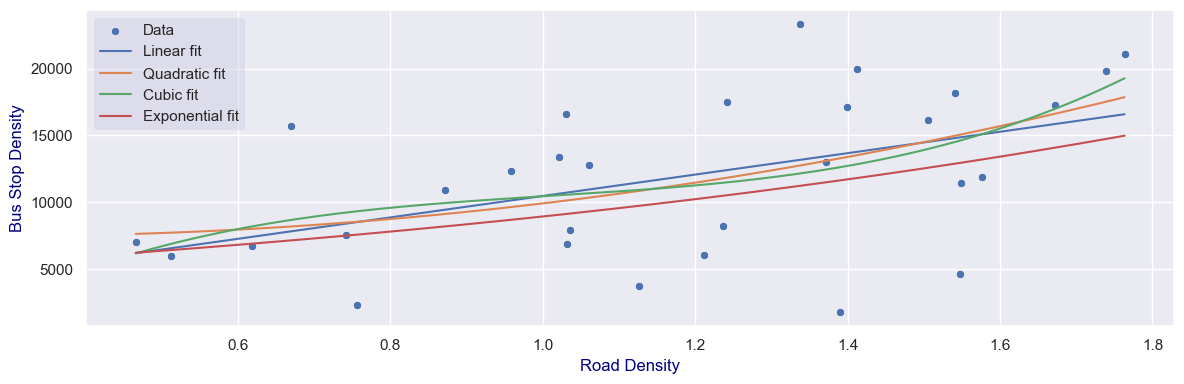

In [127]:
x = np.random.uniform(0.3, 1.8, 30)
y = 10000 * x + np.random.normal(0, 5000, size=x.size)
y = np.clip(y, 0, None)

plt.figure(figsize=(12, 4))
sns.scatterplot(x=x, y=y, label="Data")

xs = np.linspace(x.min(), x.max(), 200)

coef1 = np.polyfit(x, y, 1)
coef2 = np.polyfit(x, y, 2)
coef3 = np.polyfit(x, y, 3)

plt.plot(xs, np.polyval(coef1, xs), label="Linear fit")
plt.plot(xs, np.polyval(coef2, xs), label="Quadratic fit")
plt.plot(xs, np.polyval(coef3, xs), label="Cubic fit")

mask = y > 0
coef_exp = np.polyfit(x[mask], np.log(y[mask] + 1), 1)
plt.plot(xs, np.exp(np.polyval(coef_exp, xs)) - 1, label="Exponential fit")

plt.xlabel("Road Density", color="#000080")
plt.ylabel("Bus Stop Density", color="#000080")
plt.legend(title=None, facecolor=LEGEND_COLOR, edgecolor="none", framealpha=0.4)
plt.tight_layout()


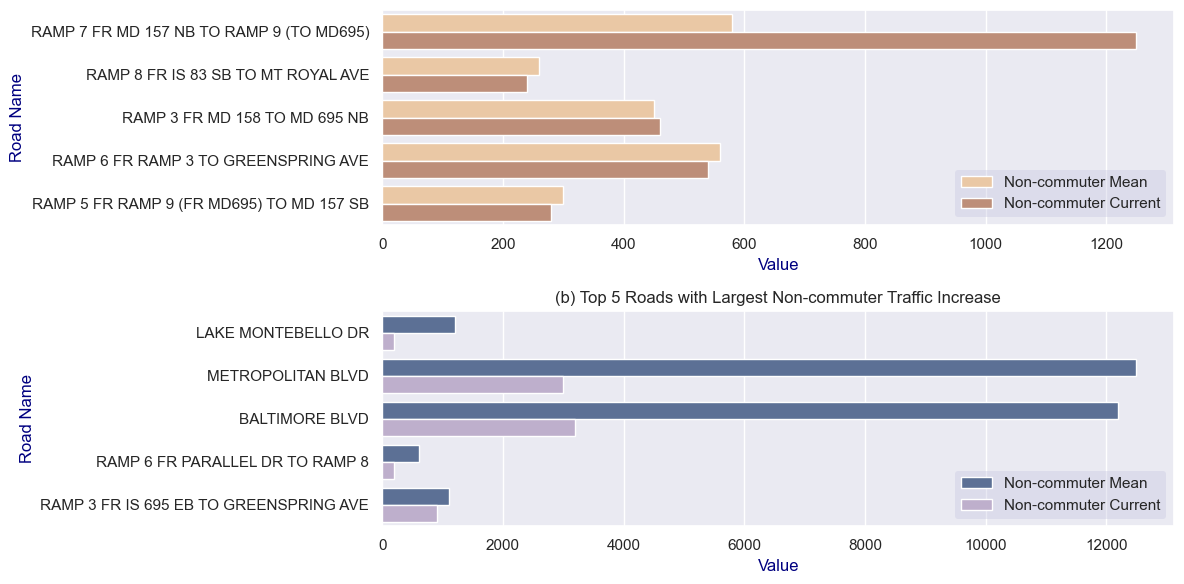

In [163]:
roads_up = [
    "RAMP 7 FR MD 157 NB TO RAMP 9 (TO MD695)",
    "RAMP 8 FR IS 83 SB TO MT ROYAL AVE",
    "RAMP 3 FR MD 158 TO MD 695 NB",
    "RAMP 6 FR RAMP 3 TO GREENSPRING AVE",
    "RAMP 5 FR RAMP 9 (FR MD695) TO MD 157 SB",
]
mean_up = [580, 260, 450, 560, 300]
current_up = [1250, 240, 460, 540, 280]

roads_down = [
    "LAKE MONTEBELLO DR",
    "METROPOLITAN BLVD",
    "BALTIMORE BLVD",
    "RAMP 6 FR PARALLEL DR TO RAMP 8",
    "RAMP 3 FR IS 695 EB TO GREENSPRING AVE",
]
mean_down = [1200, 12500, 12200, 600, 1100]
current_down = [200, 3000, 3200, 200, 900]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

up_df = pd.DataFrame({
    "Road": roads_up + roads_up,
    "Value": mean_up + current_up,
    "Type": ["Non-commuter Mean"] * len(mean_up) + ["Non-commuter Current"] * len(current_up)
})

sns.barplot(data=up_df, y="Road", x="Value", hue="Type", ax=axes[0], palette=[LIGHT_ORANGE, DARK_ORANGE])
axes[0].set_ylabel("Road Name", color="#000080")
axes[0].set_xlabel("Value", color="#000080")
axes[0].legend(title=None, loc="best", facecolor=LEGEND_COLOR, edgecolor="none", framealpha=0.4)


down_df = pd.DataFrame({
    "Road": roads_down + roads_down,
    "Value": mean_down + current_down,
    "Type": ["Non-commuter Mean"] * len(mean_down) + ["Non-commuter Current"] * len(current_down)
})

sns.barplot(data=down_df, y="Road", x="Value", hue="Type", ax=axes[1], palette=[DARK_BLUE, LIGHT_PURPLE])
axes[1].set_ylabel("Road Name", color="#000080")
axes[1].set_xlabel("Value", color="#000080")
axes[1].set_title("(b) Top 5 Roads with Largest Non-commuter Traffic Increase")
axes[1].legend(title=None, loc="best", facecolor=LEGEND_COLOR, edgecolor="none", framealpha=0.4)

plt.tight_layout()
